In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.io

from sklearn import (
    metrics,
    preprocessing,
)

print(np.__version__)
print(pd.__version__)

1.26.4
2.2.2


# Importando Datos

In [3]:
metadata={}
archivo = "datos_oficiales_algarrobina.xlsx"  # Nombre del archivo ya subido a la carpeta
rsln = 2  # resolucion de la cámara
data = pd.read_excel(archivo, sheet_name=None, engine="openpyxl") # Lee el archivo con todas sus hojas
for hoja in data.keys(): #crea matrices de datos de cada hoja cogiendo solo los datos necesarios
    metadata[hoja] = data[hoja].iloc[1:, 1:5]
    metadata[hoja].columns = ['muestra', 'adul', 'rep', 'scan']
    data[hoja] = data[hoja].iloc[1:, 5:]
    data[hoja].columns = np.arange(1100, 1100 + rsln * data[hoja].shape[1], rsln)  # Asigna números secuenciales desde 1100 a las columnas

In [4]:
for key, df in metadata.items():
    print(f"Clave actual: {key}")
    print("DataFrame correspondiente:")
    print(df)

Clave actual: 0%
DataFrame correspondiente:
    muestra adul rep scan
1         1    0   3    0
2         1    0   3    1
3         1    0   3    2
4         1    0   3    3
5         1    0   3    4
..      ...  ...  ..  ...
447       9    0   3   45
448       9    0   3   46
449       9    0   3   47
450       9    0   3   48
451       9    0   3   49

[451 rows x 4 columns]
Clave actual: 10%
DataFrame correspondiente:
     muestra adul rep scan
1          1    1   4    0
2          1    1   4    1
3          1    1   4    2
4          1    1   4    3
5          1    1   4    4
...      ...  ...  ..  ...
1302       9    2   3   46
1303       9    2   3   47
1304       9    2   3   48
1305       9    2   3   49
1306       9    2   3   50

[1306 rows x 4 columns]
Clave actual: 20%
DataFrame correspondiente:
     muestra adul rep scan
1          1    1   1    0
2          1    1   1    1
3          1    1   1    2
4          1    1   1    3
5          1    1   1    4
...      ...  ...  

### Convirtiendo de Reflectancia a Absorbancia

In [5]:
# Diccionario con los DataFrames convertidos de reflectancia a absorbancia 
data_abs = {key: np.log10(1 / df) for key, df in data.items()}
#Imprimir nueva data
for key, df in data_abs.items():
    print(f"Clave actual: {key}")
    print("DataFrame correspondiente:")
    print(df)

Clave actual: 0%
DataFrame correspondiente:
         1100      1102      1104      1106      1108      1110      1112  \
1    1.304780  1.302949  1.303957  1.307110  1.308586  1.308196  1.309905   
2    1.304386  1.305338  1.308194  1.311279  1.312260  1.311804  1.312438   
3    1.304202  1.305461  1.306964  1.309170  1.310874  1.311256  1.311967   
4    1.305694  1.306022  1.306745  1.308575  1.311103  1.313157  1.313727   
5    1.307653  1.306408  1.308612  1.311856  1.311977  1.309954  1.310361   
..        ...       ...       ...       ...       ...       ...       ...   
447  1.096519  1.097880  1.097179  1.096255  1.096951  1.098533  1.099256   
448  1.099173  1.099405  1.099439  1.099986  1.100286  1.099344  1.097986   
449  1.096811  1.096982  1.099117  1.100760  1.099756  1.097643  1.097767   
450  1.100382  1.098238  1.097054  1.097995  1.098825  1.098027  1.097428   
451  1.099781  1.099131  1.098497  1.098698  1.099282  1.099613  1.099908   

         1114      1116      11

### Graficando Data original

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def graficar_espectros(datos, hojas=None, muestras=None, reps=None, titulo_extra="",y_scale_std=False):
    """
    Grafica espectros NIR (absorbancia) filtrando por hojas, muestras y repeticiones.
    
    Parámetros:
    - datos: diccionario con DataFrames de absorbancia (clave: nivel de adulteración)
    - hojas: lista o valor único de claves a graficar (por defecto todas)
    - muestras: lista o valor único de muestras a incluir
    - reps: lista o valor único de repeticiones a incluir
    - titulo_extra: texto adicional para el título (ej. "Filtro SG")
    """
    global metadata  # asumimos que metadata está definido globalmente
    
    # 1. Determinar hojas a graficar
    if hojas is None:
        hojas = list(datos.keys())
    elif isinstance(hojas, (str, int, float)):
        hojas = [hojas]
    hojas = [h for h in hojas if h in datos]
    if not hojas:
        print("No hay hojas válidas para graficar.")
        return

    plt.figure(figsize=(7, 6))
    
    # 2. Recopilar información de las filas que cumplen los filtros
    filas_info = []
    for hoja in hojas:
        df_meta = metadata[hoja]
        mask = pd.Series(True, index=df_meta.index)
        if muestras is not None:
            if not isinstance(muestras, list):
                muestras = [muestras]
            mask &= df_meta['muestra'].isin(muestras)
        if reps is not None:
            if not isinstance(reps, list):
                reps = [reps]
            mask &= df_meta['rep'].isin(reps)
        idx_filas = df_meta.index[mask]
        for idx in idx_filas:
            filas_info.append({
                'hoja': hoja,
                'muestra': df_meta.loc[idx, 'muestra'],
                'rep': df_meta.loc[idx, 'rep'],
                'idx': idx
            })
    
    if not filas_info:
        print("No hay datos con los filtros especificados.")
        plt.close()
        return
    
    # 3. Determinar grupo de leyenda
    if len(hojas) > 1:
        grupo_leyenda = 'hoja'
        items_leyenda = sorted(set(f['hoja'] for f in filas_info))
    else:
        muestras_unicas = set(f['muestra'] for f in filas_info)
        if len(muestras_unicas) > 1:
            grupo_leyenda = 'muestra'
            items_leyenda = sorted(muestras_unicas)
        else:
            reps_unicas = set(f['rep'] for f in filas_info)
            if len(reps_unicas) > 1:
                grupo_leyenda = 'rep'
                items_leyenda = sorted(reps_unicas)
            else:
                grupo_leyenda = None
                items_leyenda = None
    
    # 4. Asignar colores
    if items_leyenda:
        paleta = sns.color_palette("viridis", len(items_leyenda))
        colores = dict(zip(items_leyenda, paleta))
    else:
        colores = {'default': 'blue'}
    
    # 5. Graficar por hoja
    for hoja in hojas:
        idx_hoja = [f['idx'] for f in filas_info if f['hoja'] == hoja]
        if not idx_hoja:
            continue
        df_abs_hoja = datos[hoja].loc[idx_hoja]
        df_meta_hoja = metadata[hoja].loc[idx_hoja]
        
        # Líneas individuales
        for idx in df_abs_hoja.index:
            if grupo_leyenda == 'hoja':
                color = colores[hoja]
            elif grupo_leyenda == 'muestra':
                color = colores[df_meta_hoja.loc[idx, 'muestra']]
            elif grupo_leyenda == 'rep':
                color = colores[df_meta_hoja.loc[idx, 'rep']]
            else:
                color = 'blue'
            plt.plot(df_abs_hoja.columns, df_abs_hoja.loc[idx],
                     color=color, alpha=0.2, linewidth=0.7)
        
        # Promedios
        if grupo_leyenda == 'hoja':
            promedio = df_abs_hoja.mean()
            plt.plot(promedio.index, promedio,
                     color=colores[hoja], linewidth=3,
                     label=f"Hoja {hoja}")
        elif grupo_leyenda == 'muestra':
            for muestra_val, grupo in df_abs_hoja.groupby(df_meta_hoja['muestra']):
                promedio = grupo.mean()
                plt.plot(promedio.index, promedio,
                         color=colores[muestra_val], linewidth=3,
                         label=f"Muestra {muestra_val}")
        elif grupo_leyenda == 'rep':
            for rep_val, grupo in df_abs_hoja.groupby(df_meta_hoja['rep']):
                promedio = grupo.mean()
                plt.plot(promedio.index, promedio,
                         color=colores[rep_val], linewidth=3,
                         label=f"Rep {rep_val}")
        else:
            promedio = df_abs_hoja.mean()
            plt.plot(promedio.index, promedio,
                     color='blue', linewidth=3, label='Promedio')
    
    # 6. Título y etiquetas
    partes_titulo = ["Espectros NIR"]
    if titulo_extra:
        partes_titulo.append(titulo_extra)
    if hojas:
        if len(hojas) == 1:
            partes_titulo.append(f"Hoja: {hojas[0]}")
    if muestras:
        if isinstance(muestras, list):
            m_str = ', '.join(map(str, muestras))
        else:
            m_str = str(muestras)
        partes_titulo.append(f"Muestras: {m_str}")
    if reps:
        if isinstance(reps, list):
            r_str = ', '.join(map(str, reps))
        else:
            r_str = str(reps)
        partes_titulo.append(f"Reps: {r_str}")
    
    plt.title(" | ".join(partes_titulo), fontsize=14)
    plt.xlabel("Longitud de onda (nm)", fontsize=12)
    plt.ylabel("Absorbancia", fontsize=12)
    plt.grid(alpha=0.2)
    
    if grupo_leyenda and items_leyenda:
        plt.legend(title=grupo_leyenda.capitalize(),
                   loc='best',
                   frameon=True,
                   fancybox=True,
                   shadow=True)
    
    # Escala Y estándar si se solicita
    if y_scale_std:
        plt.ylim(1, 3.5)
        plt.yticks(np.arange(1, 3.51, 0.25))
        
    plt.tight_layout()

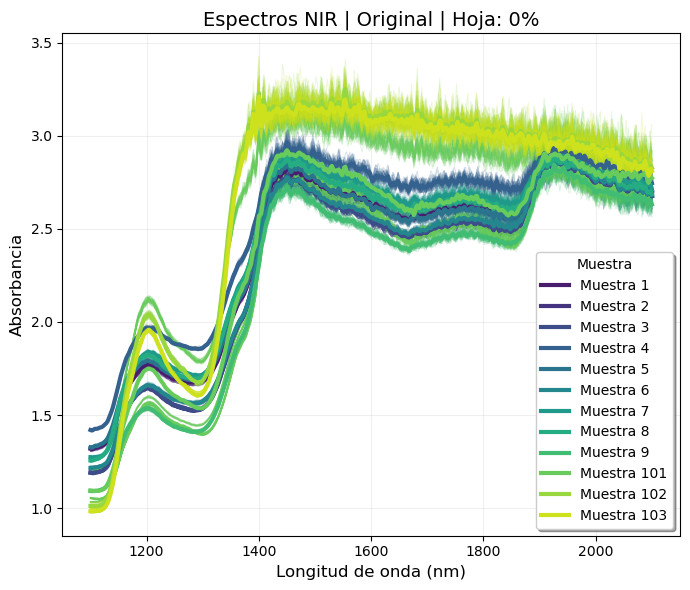

In [12]:
graficar_espectros(data_abs, hojas=['0%'],[1,2,3,4,5,6,7,8,9],titulo_extra="Original")
graficar_espectros(data_abs, hojas=['100%'],titulo_extra="Original")
# Guardar la figura actual
plt.savefig(f"grafica_muestraspuras_vs_adulterantes.png", dpi=150, bbox_inches='tight')
plt.show()

# Pretratamiento de Datos
## Sabinsky Golay (SG)

In [7]:
#APLICANDO FILTRO SG
from scipy.signal import savgol_filter

# Parámetros del filtro Savitzky-Golay
window_size = 11  # Tamaño de la ventana (debe ser impar)
poly_order = 2    # Orden del polinomio

# Aplicar el filtro a cada DataFrame dentro del diccionario, ADEMAS convierte el diccionario NUMPY en DATAFRAME
data_abs_sg = {key: pd.DataFrame(savgol_filter(df, window_length=window_size, polyorder=poly_order, axis=1), 
                                 columns=df.columns, index=df.index) 
               for key, df in data_abs.items()}


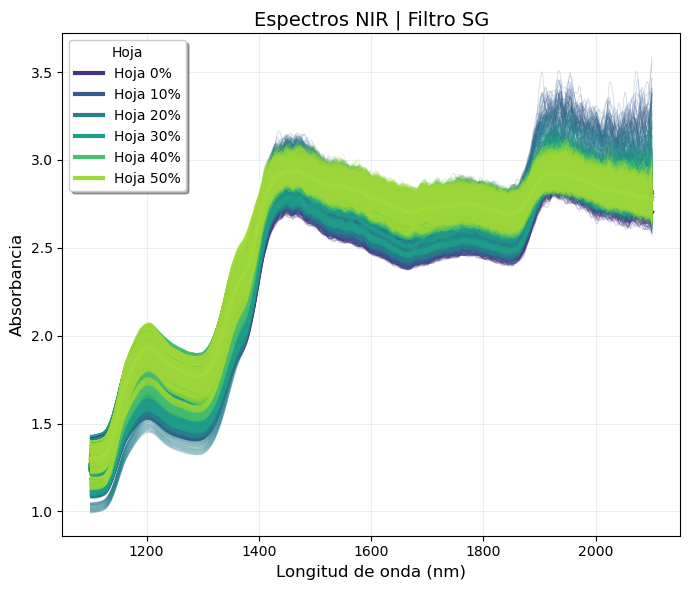

In [12]:
## GRAFICANDO CON FILTRO SG
import seaborn as sns
diccionario = data_abs_sg  #Poner diccionario a graficar
tit_graf = "Filtro SG"  #Poner titulo de filtro de gráfico

graficar_espectros(diccionario, hojas=['0%','10%','20%','30%','40%','50%'], titulo_extra=tit_graf)
# Guardar la figura actual
plt.savefig(f"grafica_{tit_graf}_general.png", dpi=150, bbox_inches='tight')
plt.show()


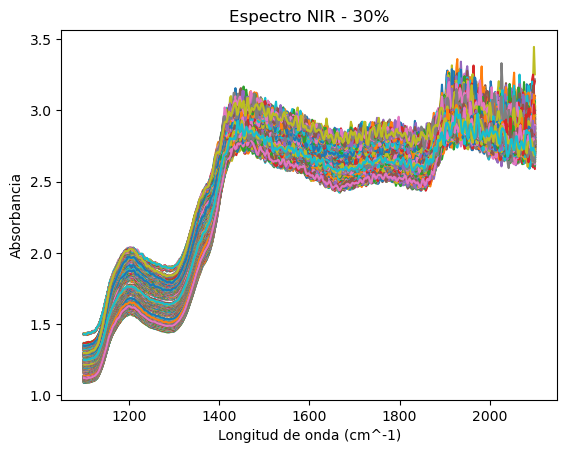

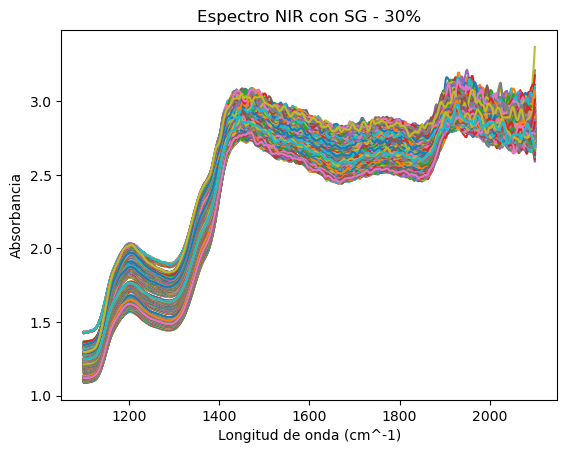

In [13]:
hoja= "30%" #Porcentaje adulteración a graficar y pretratado# Convertir a DataFrame antes de graficar

for i in range(data_abs[hoja] .shape[0]): 
    plt.plot(data_abs[hoja].columns,data_abs[hoja].iloc[i, :])
    
plt.xlabel("Longitud de onda (cm^-1)")
plt.ylabel("Absorbancia")
plt.title(f"Espectro NIR - {hoja}")
plt.show()


for i in range(data_abs_sg[hoja].shape[0]): 
    plt.plot(data_abs_sg[hoja].columns, data_abs_sg[hoja].iloc[i, :])
    
plt.xlabel("Longitud de onda (cm^-1)")
plt.ylabel("Absorbancia")
plt.title(f"Espectro NIR con SG - {hoja}")
plt.show()

## Multiplicative Scatter Correction (MSC)

In [8]:
from scipy.stats import linregress

# REFERENCIA: Con el espectro promedio (Se podría cambir con otra referencia con un espectro de menos ruido)
mean_spectrum = np.mean(pd.concat(data_abs.values()), axis=0)
    
def msc_funcion (df, mean_spectrum):
    """
    Parámetros:
      df: DataFrame de un %
    Retorna:
      DataFrame de un % con MSC aplicado, usando el promedio de todos los espectros como referencia.
    """
    # Crear un array para almacenar los datos corregidos
    corrected = np.zeros_like(df.values)
    
    for i in range(df.shape[0]):
        # Ajuste lineal entre el espectro y la referencia
        slope, intercept, _, _, _ = linregress(mean_spectrum, df.iloc[i, :])
        # Aplicar la corrección: restar la intersección y dividir entre la pendiente
        corrected[i, :] = (df.iloc[i, :] - intercept) / slope
        
    return pd.DataFrame(corrected, columns=df.columns, index=df.index)

# Aplicar la funcion MSC a toda la data.
data_abs_msc = {key: msc_funcion(df,mean_spectrum) for key, df in data_abs.items()}


## Transformacion de variable normal estandar (SNV)

In [10]:
def snv(df):
    """
    Recuerda que KeepdIms es para que haya la misma cantidad de filas pero con solo 1 columna
    """
    mean = df.values.mean(axis=1, keepdims=True)  
    std = df.values.std(axis=1, keepdims=True) 
    corrected = (df.values - mean) / std  # Aplicamos SNV    
    return pd.DataFrame(corrected, columns=df.columns, index=df.index)

# Aplicar la funcion SNV a toda la data.
data_abs_snv = {key: snv(df) for key, df in data_abs.items()}


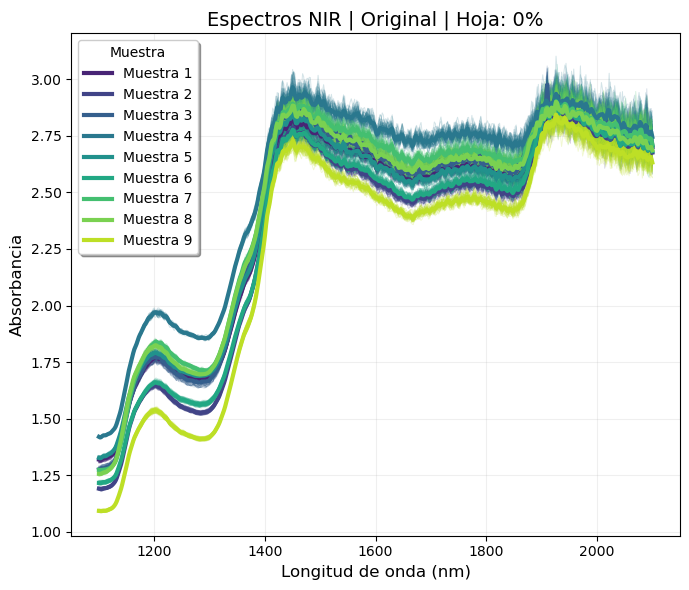

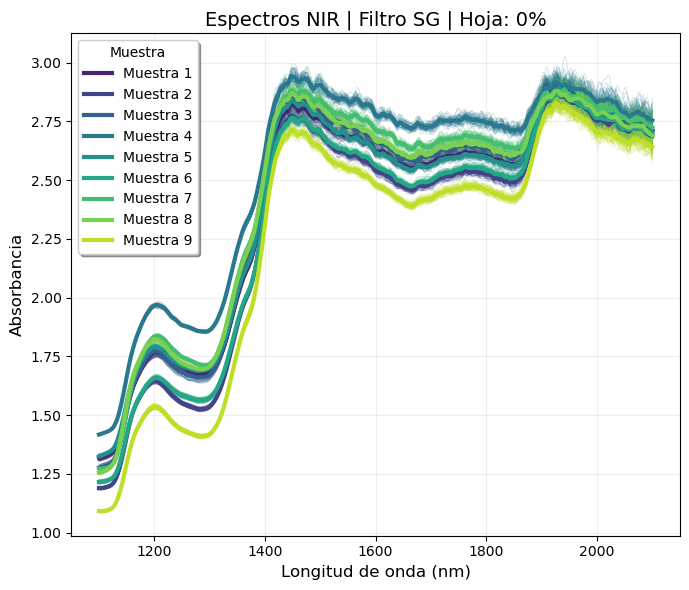

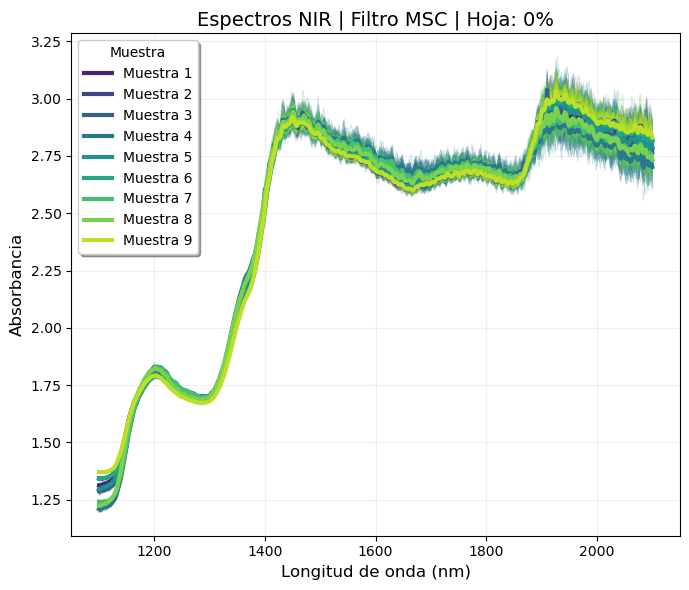

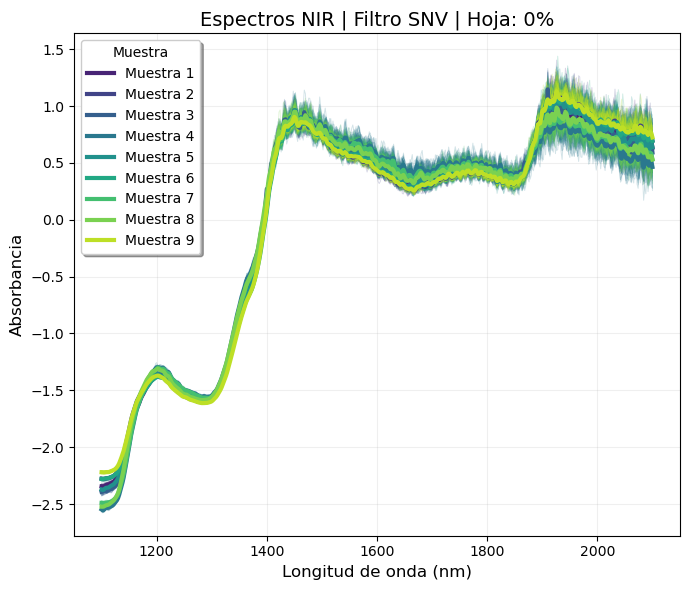

In [11]:
diccionarios = [data_abs, data_abs_sg, data_abs_msc, data_abs_snv]  # lista de diccionarios
tit_graf = ["Original", "Filtro SG", "Filtro MSC", "Filtro SNV"]  # títulos

for i, datos in enumerate(diccionarios):
    graficar_espectros(datos, hojas=['0%'], titulo_extra=tit_graf[i])
    plt.savefig(f"grafica_{tit_graf[i]}_general.png", dpi=150, bbox_inches='tight')
    plt.show()

# Construcción de modelos
## Definición de entrenamiento y prueba
### Creando un diccionario con todos los datos

In [19]:
data_dict = {} ## Diccionario GENERAL de los datos originales y los datos preprocesados para poder entrenar

# Diccionarios con datos actuales (puedes aumentar uno nuevo)
data_sets = {
    "orig": data_abs,
    "sg": data_abs_sg,
    "msc": data_abs_msc,
    "snv": data_abs_snv
}

for name, data in data_sets.items():
    X_all = []
    Y_all = []

    for key, df in data.items():
        X_all.append(df.values)   # Agregar los valores del DataFrame a la lista
        Y_all.extend([float(key.strip("%"))] * df.shape[0])  # Asignar % de adulteración

    # Convertir listas a arrays de NumPy
    X_all = np.vstack(X_all)  # Unir matrices en un solo array
    Y_all = np.array(Y_all).reshape(-1, 1)  # Convierte la lista en un array de NumPy y asegura que sea 2D (x,1 col) y no (x,)

    # Guardar en el diccionario general
    data_dict[name] = {"X": X_all, "Y": Y_all}

# Verificar dimensiones
for key, value in data_dict.items():
    print(f"Dataset: {key}")
    print(f"Dimensiones de X: {value['X'].shape}")
    print(f"Dimensiones de Y: {value['Y'].shape}\n")


Dataset: orig
Dimensiones de X: (7196, 501)
Dimensiones de Y: (7196, 1)

Dataset: sg
Dimensiones de X: (7196, 501)
Dimensiones de Y: (7196, 1)

Dataset: msc
Dimensiones de X: (7196, 501)
Dimensiones de Y: (7196, 1)

Dataset: snv
Dimensiones de X: (7196, 501)
Dimensiones de Y: (7196, 1)



In [21]:
# Guardar el diccionario en un archivo
import pickle

with open("data_dict_complete.pkl", "wb") as f:
    pickle.dump(data_dict, f)

In [22]:
from sklearn.model_selection import train_test_split

# Parámetros de la división
prueba = 0.2  # Tamaño del conjunto de prueba (20%)
seed = 2025   # Semilla para reproducibilidad

split_data_dict = {} # Diccionario para almacenar los datos de entrenamiento y prueba

for key, data in data_dict.items():
    X_train, X_test, Y_train, Y_test = train_test_split(
        data["X"], data["Y"], test_size=prueba, random_state=seed
    )
    
    # Guardamos los conjuntos en el diccionario
    split_data_dict[key] = {
    "train": {"X": X_train, "Y": Y_train}, 
    "test": {"X": X_test, "Y": Y_test}  
    }
    
# Imprimir información sobre la división
for key, data in split_data_dict.items():
    print(f"Dataset: {key}")
    print(f"Tamaño de entrenamiento: {1 - prueba} | prueba: {prueba}")
    print(f"Min/Max de X_train: {data['train']['X'].min()}, {data['train']['X'].max()}")
    print(f"Min/Max de X_test: {data['test']['X'].min()}, {data['test']['X'].max()}")
    print(f"Tamaño -> X_train: {data['train']['X'].shape}, X_test: {data['test']['X'].shape}, "
          f"Y_train: {data['train']['Y'].shape}, Y_test: {data['test']['Y'].shape}\n")


Dataset: orig
Tamaño de entrenamiento: 0.8 | prueba: 0.2
Min/Max de X_train: 0.9745220898716793, 3.9621314639076735
Min/Max de X_test: 0.9748580503748066, 3.726623659510136
Tamaño -> X_train: (5756, 501), X_test: (1440, 501), Y_train: (5756, 1), Y_test: (1440, 1)

Dataset: sg
Tamaño de entrenamiento: 0.8 | prueba: 0.2
Min/Max de X_train: 0.9752886127765829, 3.5910473108689374
Min/Max de X_test: 0.9755120416313424, 3.4683186516323525
Tamaño -> X_train: (5756, 501), X_test: (1440, 501), Y_train: (5756, 1), Y_test: (1440, 1)

Dataset: msc
Tamaño de entrenamiento: 0.8 | prueba: 0.2
Min/Max de X_train: 1.0404674721382379, 3.6052977194138074
Min/Max de X_test: 1.0405483671078637, 3.396062387918411
Tamaño -> X_train: (5756, 501), X_test: (1440, 501), Y_train: (5756, 1), Y_test: (1440, 1)

Dataset: snv
Tamaño de entrenamiento: 0.8 | prueba: 0.2
Min/Max de X_train: -2.811475760461824, 2.2578953916480784
Min/Max de X_test: -2.8084884803188337, 1.846030072642991
Tamaño -> X_train: (5756, 501), X_

In [22]:
# Guardar el diccionario en un archivo
import pickle
obj = {
    "prueba": prueba,
    "split": split_data_dict
}

with open("split_data_dict.pkl", "wb") as f:
    pickle.dump(obj, f)
